In [1]:
import numpy as np
import openpyxl

In [2]:
workbook = openpyxl.load_workbook('MSI1.xlsx')

In [3]:
# Select the worksheet
worksheet = workbook['main']
start_row = 3
start_col = 1
end_row = 20
end_col = 4

In [4]:
# Read the cell values in the specified range
for row in range(start_row, end_row + 1):
    for col in range(start_col, end_col + 1):
        cell_value = worksheet.cell(row=row, column=col).value
        print(f"Row {row}, Column {col}: {cell_value}")

Row 3, Column 1: 9(A)
Row 3, Column 2: 0
Row 3, Column 3: 0
Row 3, Column 4: 0
Row 4, Column 1: 10(A)
Row 4, Column 2: 0
Row 4, Column 3: 0
Row 4, Column 4: 0
Row 5, Column 1: 11(A)
Row 5, Column 2: 0.000408645114420632
Row 5, Column 3: 0
Row 5, Column 4: 0
Row 6, Column 1: 12(A)
Row 6, Column 2: 0.00367780602978568
Row 6, Column 3: 0.000312151616499442
Row 6, Column 4: 0.000439206500256203
Row 7, Column 1: 13(A)
Row 7, Column 2: 0.0319197239375227
Row 7, Column 3: 0.001917502787068
Row 7, Column 4: 0.00248883683478515
Row 8, Column 1: 14(A)
Row 8, Column 2: 0.135261532873229
Row 8, Column 3: 0.0108807134894091
Row 8, Column 4: 0.0137618036746943
Row 9, Column 1: 15(A)
Row 9, Column 2: 0.0828641482019615
Row 9, Column 3: 0.0479821627647714
Row 9, Column 4: 0.0703096405826806
Row 10, Column 1: 16(A)
Row 10, Column 2: 0.0632491827097711
Row 10, Column 3: 0.0999331103678929
Row 10, Column 4: 0.172242149183807
Row 11, Column 1: 17(A)
Row 11, Column 2: 0.0955321467490011
Row 11, Column 3: 0

In [5]:
# Close the workbook
workbook.close()

In [6]:
import pandas as pd

In [7]:
fname = 'MSI1.xlsx'
sname = 'main'
df = pd.DataFrame(pd.read_excel(fname, 
                               sheet_name=sname, 
                               usecols='B:AC', 
                               nrows=20, 
                               skiprows=1))

In [8]:
# Print the DataFrame
print(df)


        STR1  Unnamed: 2  Unnamed: 3  Unnamed: 4  Unnamed: 5  Unnamed: 6  \
0   0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
1   0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
2   0.000409    0.000000    0.000000    0.000000    0.000000    0.000151   
3   0.003678    0.000312    0.000439    0.000000    0.000000    0.000378   
4   0.031920    0.001918    0.002489    0.000095    0.000238    0.002682   
5   0.135262    0.010881    0.013762    0.000851    0.002302    0.017678   
6   0.082864    0.047982    0.070310    0.003546    0.011232    0.093828   
7   0.063249    0.099933    0.172242    0.014893    0.046515    0.222407   
8   0.095532    0.151260    0.200791    0.063496    0.149349    0.159968   
9   0.134308    0.167715    0.132128    0.205711    0.288022    0.118531   
10  0.171404    0.287670    0.230144    0.436811    0.283894    0.211151   
11  0.116282    0.075808    0.054352    0.112666    0.066122    0.051976   
12  0.031329

In [9]:
import pandas as pd
import numpy as np

def analyze_microsatellites(df):
    """
    Анализирует DataFrame с микросателлитами
    Возвращает энтропию и std для каждого образца (столбца)
    """
    
    def shannon_entropy(column):
        """Энтропия Шеннона для распределения длин микросателлита"""
        clean_col = column[column > 0]
        if len(clean_col) == 0:
            return 0
        probabilities = clean_col / clean_col.sum()
        return -np.sum(probabilities * np.log(probabilities))
    
    # Вычисляем метрики
    entropy_results = df.apply(shannon_entropy)
    std_results = df.std()
    
    # Создаем итоговый DataFrame
    analysis_df = pd.DataFrame({
        'Sample': df.columns,
        'Shannon_Entropy': entropy_results.values,
        'Standard_Deviation': std_results.values
    })
    
    return analysis_df

# Использование
# df = pd.read_csv('microsatellites.tsv', sep='\t', index_col=0)
results = analyze_microsatellites(df)
print(results)

         Sample  Shannon_Entropy  Standard_Deviation
0          STR1         2.119336            0.057748
1    Unnamed: 2         1.767560            0.077882
2    Unnamed: 3         1.789968            0.075913
3    Unnamed: 4         1.345465            0.106017
4    Unnamed: 5         1.526252            0.090551
5    Unnamed: 6         1.820382            0.074753
6    Unnamed: 7         1.824971            0.075765
7    Unnamed: 8         2.112097            0.060660
8    Unnamed: 9         1.648938            0.091708
9   Unnamed: 10         1.932000            0.068661
10  Unnamed: 11         1.479830            0.092223
11  Unnamed: 12         1.736311            0.087952
12  Unnamed: 13         1.325746            0.094595
13  Unnamed: 14         1.390533            0.087431
14  Unnamed: 15         1.277916            0.098199
15  Unnamed: 16         1.293213            0.097119
16  Unnamed: 17         1.296956            0.097687
17  Unnamed: 18         1.373756            0.

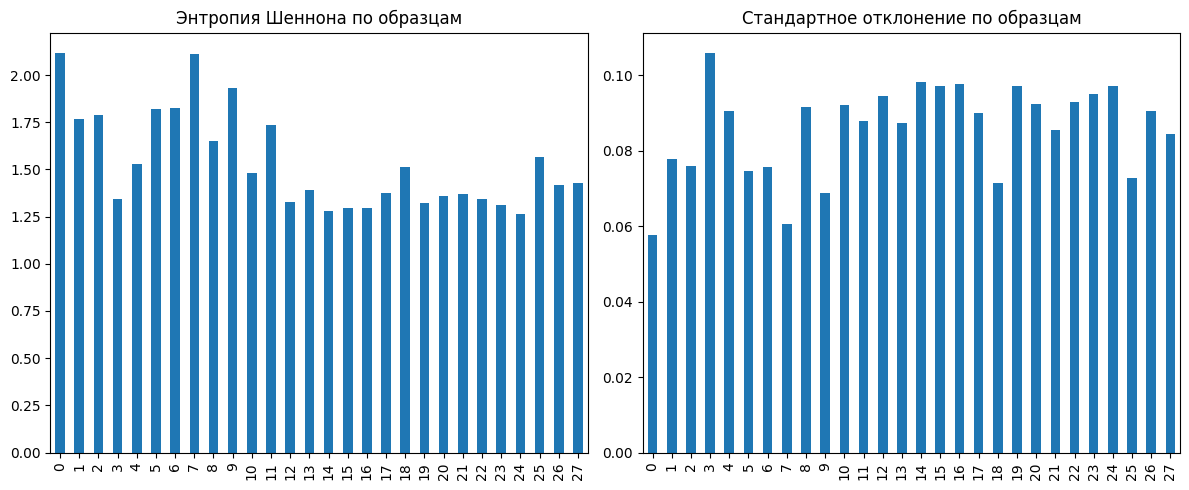

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
results['Shannon_Entropy'].plot(kind='bar', title='Энтропия Шеннона по образцам')
plt.subplot(1, 2, 2)
results['Standard_Deviation'].plot(kind='bar', title='Стандартное отклонение по образцам')
plt.tight_layout()
plt.show()

In [11]:
df.to_csv('output.tsv', sep='\t', index=False)

In [12]:
import pandas as pd
import numpy as np

def extract_all_str_data_corrected(fname, sheet_name, n_str=14, n_rows_per_str=20, header_rows=2, gap_rows=2):
    """
    Извлекает все STR данные с правильным смещением
    
    Parameters:
    - fname: имя файла
    - sheet_name: имя листа  
    - n_str: количество STR регионов (14)
    - n_rows_per_str: строк на каждый STR (20)
    - header_rows: строк заголовка до первого STR (1)
    - gap_rows: количество пустых строк между STR (2)
    """
    
    full_data = pd.read_excel(fname, sheet_name=sheet_name, header=None)
    
    str_dataframes = {}
    
    for i in range(n_str):
        # ПРАВИЛЬНАЯ ФОРМУЛА: header_rows + i * (n_rows_per_str + gap_rows)
        start_idx = header_rows + i * (n_rows_per_str + gap_rows)
        end_idx = start_idx + n_rows_per_str
        
        print(f"STR{i+1}: строки {start_idx}-{end_idx}")
        
        # Извлекаем данные
        str_df = full_data.iloc[start_idx:end_idx, 1:29].copy()
        
        # Преобразуем в числовой формат
        str_df = str_df.apply(pd.to_numeric, errors='coerce')
        
        # Проверяем данные
        non_nan_count = str_df.notna().sum().sum()
        print(f"  Не-NaN значений: {non_nan_count}/{str_df.size}")
        
        if non_nan_count == 0:
            print(f"  ⚠️  ВНИМАНИЕ: STR{i+1} - все данные NaN! Проверяем смещение...")
            # Пробуем альтернативные смещения
            for offset in [0, 1, -1, 2, -2]:
                test_start = start_idx + offset
                test_end = test_start + n_rows_per_str
                if test_start >= 0 and test_end <= len(full_data):
                    test_df = full_data.iloc[test_start:test_end, 1:29].apply(pd.to_numeric, errors='coerce')
                    test_nan = test_df.notna().sum().sum()
                    if test_nan > 0:
                        print(f"  ✅ Найдены данные со смещением {offset}")
                        str_df = test_df.copy()
                        break
        
        # Устанавливаем заголовки и индексы
        str_df.columns = [f"Sample_{j+1}" for j in range(28)]
        str_df.index = [f"Length_{j+1}" for j in range(n_rows_per_str)]
        
        str_name = f"STR{i+1}"
        str_dataframes[str_name] = str_df
        
    return str_dataframes

# Использование
fname = 'MSI1.xlsx'
sname = 'main'
all_str_data = extract_all_str_data_corrected(fname, sname, n_str=14)

# Доступ к данным
str1_df = all_str_data['STR1']
str2_df = all_str_data['STR2']
print(str1_df)
print(str2_df)

STR1: строки 2-22
  Не-NaN значений: 560/560
STR2: строки 24-44
  Не-NaN значений: 560/560
STR3: строки 46-66
  Не-NaN значений: 560/560
STR4: строки 68-88
  Не-NaN значений: 560/560
STR5: строки 90-110
  Не-NaN значений: 560/560
STR6: строки 112-132
  Не-NaN значений: 560/560
STR7: строки 134-154
  Не-NaN значений: 560/560
STR8: строки 156-176
  Не-NaN значений: 560/560
STR9: строки 178-198
  Не-NaN значений: 560/560
STR10: строки 200-220
  Не-NaN значений: 560/560
STR11: строки 222-242
  Не-NaN значений: 560/560
STR12: строки 244-264
  Не-NaN значений: 560/560
STR13: строки 266-286
  Не-NaN значений: 560/560
STR14: строки 288-308
  Не-NaN значений: 560/560
           Sample_1  Sample_2  Sample_3  Sample_4  Sample_5  Sample_6  \
Length_1   0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
Length_2   0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
Length_3   0.000409  0.000000  0.000000  0.000000  0.000000  0.000151   
Length_4   0.003678  0.000312  0.000439  

In [13]:
# Анализ конкретного STR
all_str_data = {name: df.apply(pd.to_numeric, errors='coerce') 
                for name, df in all_str_data.items()}

str1_data = all_str_data['STR1']
entropy_str1 = str1_data.apply(lambda col: -np.sum((col[col>0]/col[col>0].sum()) * 
                                  np.log(col[col>0]/col[col>0].sum())) 
                                  if col[col>0].sum() > 0 else 0)

# Итерация по всем STR
for str_name, str_df in all_str_data.items():
    print(f"Анализируем {str_name}: {str_df.shape}")
    # Ваш анализ здесь

str3_data = all_str_data['STR3']    
print(str3_data)

Анализируем STR1: (20, 28)
Анализируем STR2: (20, 28)
Анализируем STR3: (20, 28)
Анализируем STR4: (20, 28)
Анализируем STR5: (20, 28)
Анализируем STR6: (20, 28)
Анализируем STR7: (20, 28)
Анализируем STR8: (20, 28)
Анализируем STR9: (20, 28)
Анализируем STR10: (20, 28)
Анализируем STR11: (20, 28)
Анализируем STR12: (20, 28)
Анализируем STR13: (20, 28)
Анализируем STR14: (20, 28)
           Sample_1  Sample_2  Sample_3  Sample_4  Sample_5  Sample_6  \
Length_1   0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
Length_2   0.000000  0.000000  0.000092  0.000000  0.000000  0.000694   
Length_3   0.000283  0.000083  0.001927  0.000126  0.000244  0.006295   
Length_4   0.002503  0.000875  0.010368  0.000503  0.001266  0.036662   
Length_5   0.007274  0.002875  0.046335  0.001510  0.008475  0.150488   
Length_6   0.029333  0.011375  0.168593  0.005220  0.029466  0.205110   
Length_7   0.093524  0.038707  0.032021  0.019058  0.094146  0.098829   
Length_8   0.164801  0.114120  0.

In [14]:
fname = 'MSI1.xlsx'
sname = 'main'
microsat = pd.DataFrame(pd.read_excel(fname, 
                               sheet_name=sname, 
                               usecols='B:AC', 
                               nrows=1, 
                               skiprows=21))
print(microsat)

   0 0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9  ... 0.18 0.19 0.20 0.21 0.22 0.23  \
0  N   N   N   N   S   N   N   N   N   N  ...    S    S    S    S    S    S   

  0.24 0.25 0.26 0.27  
0    S    S    S    S  

[1 rows x 28 columns]


In [15]:
def extract_razmetka_all_str_excel_numbering(fname, sheet_name, n_str=14, data_rows_per_str=20):
    """
    Извлекает разметку с учетом Excel нумерации и заменяет NaN на 'N'
    """
    
    razmetka_data = {}
    
    for i in range(n_str):
        # Excel строки: разметка в 23, 45, 67, ...
        razmetka_row_excel = 23 + i * 22
        razmetka_row_python = razmetka_row_excel - 1
        
        print(f"STR{i+1}: разметка в Excel строке {razmetka_row_excel}")
        
        # Извлекаем разметку
        razmetka_df = pd.read_excel(fname, 
                                   sheet_name=sname, 
                                   usecols='B:AC', 
                                   nrows=1, 
                                   skiprows=razmetka_row_python,
                                   header=None)
        
        # Преобразуем в список и заменяем NaN на 'N'
        razmetka_values = razmetka_df.iloc[0].tolist()
        razmetka_values_clean = ['N' if pd.isna(x) else x for x in razmetka_values]
        
        # Сохраняем в словарь
        str_name = f"STR{i+1}"
        razmetka_data[str_name] = razmetka_values_clean
        
        print(f"  Разметка (NaN→N): {razmetka_values_clean}")
    
    # Создаем DataFrame разметки
    razmetka_df = pd.DataFrame(razmetka_data)
    razmetka_df.index = [f"Sample_{j+1}" for j in range(len(razmetka_values_clean))]
    
    return razmetka_df

# Извлекаем разметку с заменой NaN на 'N'
razmetka_all_str = extract_razmetka_all_str_excel_numbering(fname, sname)

print("\n=== ПОЛНАЯ РАЗМЕТКА (NaN заменены на N) ===")
print(razmetka_all_str)

STR1: разметка в Excel строке 23
  Разметка (NaN→N): ['N', 'N', 'N', 'N', 'S', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S']
STR2: разметка в Excel строке 45
  Разметка (NaN→N): ['N', 'N', 'S', 'N', 'N', 'S', 'N', 'N', 'S', 'N', 'N', 'N', 'N', 'N', 'N', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S']
STR3: разметка в Excel строке 67
  Разметка (NaN→N): ['N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S']
STR4: разметка в Excel строке 89
  Разметка (NaN→N): ['N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'S', 'N', 'N', 'N', 'N', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S']
STR5: разметка в Excel строке 111
  Разметка (NaN→N): ['N', 'N', 'S', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'S', 'N', 'N', 'N', 'N', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S']
STR6: разметка в Excel строке

In [16]:
import numpy as np
import pandas as pd

def calculate_shannon_entropy(spectrum):
    """Вычисляет энтропию Шеннона для одного спектра"""
    clean_spectrum = spectrum[spectrum > 0].dropna()
    if len(clean_spectrum) == 0:
        return 0
    probabilities = clean_spectrum / clean_spectrum.sum()
    return -np.sum(probabilities * np.log(probabilities))

def compute_average_entropies(all_str_data, start_sample=13, end_sample=28):
    """
    Вычисляет средние энтропии Шеннона для образцов с start_sample по end_sample
    
    Parameters:
    - all_str_data: словарь с DataFrames для каждого STR
    - start_sample: начальный образец (включительно)
    - end_sample: конечный образец (включительно)
    """
    
    average_entropies = {}
    
    for str_name, str_df in all_str_data.items():
        print(f"Вычисляем энтропию для {str_name}...")
        
        # Выбираем образцы с start_sample по end_sample
        sample_columns = [f"Sample_{j}" for j in range(start_sample, end_sample + 1)]
        selected_samples = str_df[sample_columns]
        
        # Вычисляем энтропию для каждого выбранного образца
        sample_entropies = []
        for sample_col in selected_samples.columns:
            entropy = calculate_shannon_entropy(selected_samples[sample_col])
            sample_entropies.append(entropy)
        
        # Вычисляем среднюю энтропию
        avg_entropy = np.mean(sample_entropies)
        std_entropy = np.std(sample_entropies)
        
        average_entropies[str_name] = {
            'average_entropy': avg_entropy,
            'std_entropy': std_entropy,
            'min_entropy': np.min(sample_entropies),
            'max_entropy': np.max(sample_entropies),
            'n_samples': len(sample_entropies)
        }
        
        print(f"  {str_name}: средняя энтропия = {avg_entropy:.4f} ± {std_entropy:.4f}")
        print(f"    диапазон: [{np.min(sample_entropies):.4f}, {np.max(sample_entropies):.4f}]")
    
    return average_entropies

# Вычисляем средние энтропии для образцов 13-28
entropy_results = compute_average_entropies(all_str_data, start_sample=13, end_sample=28)
print(entropy_results)

Вычисляем энтропию для STR1...
  STR1: средняя энтропия = 1.3661 ± 0.0803
    диапазон: [1.2661, 1.5642]
Вычисляем энтропию для STR2...
  STR2: средняя энтропия = 0.9237 ± 0.1310
    диапазон: [0.6213, 1.0840]
Вычисляем энтропию для STR3...
  STR3: средняя энтропия = 1.4042 ± 0.0438
    диапазон: [1.3242, 1.4754]
Вычисляем энтропию для STR4...
  STR4: средняя энтропия = 1.1660 ± 0.0388
    диапазон: [1.0835, 1.2363]
Вычисляем энтропию для STR5...
  STR5: средняя энтропия = 1.0723 ± 0.1002
    диапазон: [0.7765, 1.1738]
Вычисляем энтропию для STR6...
  STR6: средняя энтропия = 1.3872 ± 0.0893
    диапазон: [1.2330, 1.5620]
Вычисляем энтропию для STR7...
  STR7: средняя энтропия = 1.3437 ± 0.0671
    диапазон: [1.1888, 1.4375]
Вычисляем энтропию для STR8...
  STR8: средняя энтропия = 1.1801 ± 0.0620
    диапазон: [1.0445, 1.2797]
Вычисляем энтропию для STR9...
  STR9: средняя энтропия = 1.3209 ± 0.0816
    диапазон: [1.1539, 1.4314]
Вычисляем энтропию для STR10...
  STR10: средняя энтроп

In [17]:
def create_entropy_array(entropy_results, str_count=14):
    """
    Создает массив средних энтропий для STR1-STR14
    """
    entropy_array = []
    str_names = []
    
    for i in range(1, str_count + 1):
        str_name = f"STR{i}"
        if str_name in entropy_results:
            entropy_array.append(entropy_results[str_name]['average_entropy'])
            str_names.append(str_name)
        else:
            entropy_array.append(np.nan)
            str_names.append(str_name)
            print(f"⚠️  Предупреждение: {str_name} не найден в данных")
    
    return np.array(entropy_array), str_names

# Создаем массив из 14 значений
entropy_array_14, str_names = create_entropy_array(entropy_results)

print("\n=== МАССИВ СРЕДНИХ ЭНТРОПИЙ ДЛЯ STR1-STR14 ===")
for i, (str_name, entropy) in enumerate(zip(str_names, entropy_array_14)):
    print(f"{str_name}: {entropy:.6f}")

print(f"\nФорма массива: {entropy_array_14.shape}")
print(f"Массив: {entropy_array_14}")


=== МАССИВ СРЕДНИХ ЭНТРОПИЙ ДЛЯ STR1-STR14 ===
STR1: 1.366149
STR2: 0.923745
STR3: 1.404226
STR4: 1.165983
STR5: 1.072259
STR6: 1.387192
STR7: 1.343723
STR8: 1.180131
STR9: 1.320855
STR10: 1.463945
STR11: 1.393920
STR12: 1.396917
STR13: 1.758201
STR14: 1.612028

Форма массива: (14,)
Массив: [1.36614943 0.92374485 1.40422601 1.16598317 1.0722588  1.38719192
 1.34372336 1.18013143 1.32085548 1.46394478 1.39391975 1.39691662
 1.75820087 1.6120275 ]


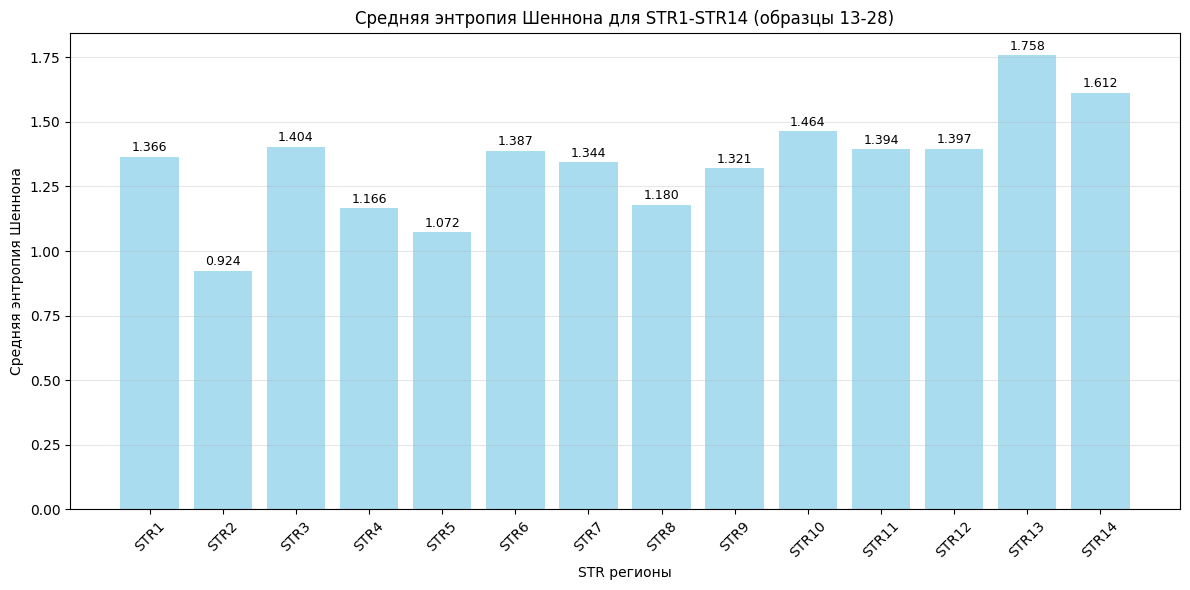

In [18]:
import matplotlib.pyplot as plt

def plot_entropy_array(entropy_array, str_names):
    """
    Визуализирует массив энтропий
    """
    plt.figure(figsize=(12, 6))
    
    # Создаем график
    bars = plt.bar(str_names, entropy_array, color='skyblue', alpha=0.7)
    
    # Добавляем значения на столбцы
    for bar, entropy in zip(bars, entropy_array):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{entropy:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.xlabel('STR регионы')
    plt.ylabel('Средняя энтропия Шеннона')
    plt.title('Средняя энтропия Шеннона для STR1-STR14 (образцы 13-28)')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Визуализируем
plot_entropy_array(entropy_array_14, str_names)

In [19]:
def analyze_entropy_array(entropy_array, str_names):
    """
    Анализирует статистику массива энтропий
    """
    print("=== СТАТИСТИКА МАССИВА ЭНТРОПИЙ ===")
    print(f"Среднее: {np.mean(entropy_array):.6f}")
    print(f"Стандартное отклонение: {np.std(entropy_array):.6f}")
    print(f"Минимум: {np.min(entropy_array):.6f} ({str_names[np.argmin(entropy_array)]})")
    print(f"Максимум: {np.max(entropy_array):.6f} ({str_names[np.argmax(entropy_array)]})")
    print(f"Медиана: {np.median(entropy_array):.6f}")
    
    # Сортируем по энтропии
    sorted_indices = np.argsort(entropy_array)
    print(f"\nСортировка по возрастанию энтропии:")
    for idx in sorted_indices:
        print(f"  {str_names[idx]}: {entropy_array[idx]:.6f}")

# Анализируем статистику
analyze_entropy_array(entropy_array_14, str_names)

=== СТАТИСТИКА МАССИВА ЭНТРОПИЙ ===
Среднее: 1.342091
Стандартное отклонение: 0.203285
Минимум: 0.923745 (STR2)
Максимум: 1.758201 (STR13)
Медиана: 1.376671

Сортировка по возрастанию энтропии:
  STR2: 0.923745
  STR5: 1.072259
  STR4: 1.165983
  STR8: 1.180131
  STR9: 1.320855
  STR7: 1.343723
  STR1: 1.366149
  STR6: 1.387192
  STR11: 1.393920
  STR12: 1.396917
  STR3: 1.404226
  STR10: 1.463945
  STR14: 1.612028
  STR13: 1.758201


In [20]:
def save_entropy_results(entropy_array, str_names, filename='entropy_results.csv'):
    """
    Сохраняет результаты в CSV файл
    """
    results_df = pd.DataFrame({
        'STR_Region': str_names,
        'Average_Shannon_Entropy': entropy_array
    })
    
    results_df.to_csv(filename, index=False, encoding='utf-8')
    print(f"Результаты сохранены в {filename}")
    
    return results_df

# Сохраняем результаты
entropy_df = save_entropy_results(entropy_array_14, str_names)

print("\n=== ТАБЛИЦА РЕЗУЛЬТАТОВ ===")
print(entropy_df)

Результаты сохранены в entropy_results.csv

=== ТАБЛИЦА РЕЗУЛЬТАТОВ ===
   STR_Region  Average_Shannon_Entropy
0        STR1                 1.366149
1        STR2                 0.923745
2        STR3                 1.404226
3        STR4                 1.165983
4        STR5                 1.072259
5        STR6                 1.387192
6        STR7                 1.343723
7        STR8                 1.180131
8        STR9                 1.320855
9       STR10                 1.463945
10      STR11                 1.393920
11      STR12                 1.396917
12      STR13                 1.758201
13      STR14                 1.612028


In [21]:

def correct_razmetka_based_on_entropy(razmetka_df, all_str_data, entropy_array, str_names, 
                                    threshold_type='std', std_multiplier=1.0):
    """
    Корректирует разметку: формально 'S' образцы с высокой энтропией → 'N'
    
    Parameters:
    - razmetka_df: исходная разметка
    - all_str_data: данные STR
    - entropy_array: массив средних энтропий для каждого STR
    - str_names: названия STR
    - threshold_type: тип порога ('std' - стандартное отклонение, 'absolute' - абсолютное значение)
    - std_multiplier: множитель для стандартного отклонения
    """
    
    # Создаем копию разметки для коррекции
    razmetka_corrected = razmetka_df.copy()
    
    # Создаем словарь для статистики коррекций
    correction_stats = {}
    
    print("=== КОРРЕКЦИЯ РАЗМЕТКИ НА ОСНОВЕ ЭНТРОПИИ ===")
    
    for i, str_name in enumerate(str_names):
        if str_name not in all_str_data:
            continue
            
        str_df = all_str_data[str_name]
        str_razmetka = razmetka_df[str_name]
        
        # Вычисляем энтропию для каждого образца в этом STR
        sample_entropies = {}
        for sample_col in str_df.columns:
            entropy = calculate_shannon_entropy(str_df[sample_col])
            sample_entropies[sample_col] = entropy
        
        # Определяем порог для этого STR
        str_avg_entropy = entropy_array[i]
        
        if threshold_type == 'std':
            # Используем стандартное отклонение энтропий образцов
            entropies_list = list(sample_entropies.values())
            str_std_entropy = np.std(entropies_list)
            threshold = str_avg_entropy + std_multiplier * str_std_entropy
        else:
            # Абсолютный порог (например, среднее + фиксированное значение)
            threshold = str_avg_entropy + 0.1  # пример абсолютного порога
        
        print(f"\n{str_name}:")
        print(f"  Средняя энтропия: {str_avg_entropy:.4f}")
        if threshold_type == 'std':
            print(f"  STD энтропии: {str_std_entropy:.4f}")
        print(f"  Порог коррекции: {threshold:.4f}")
        
        # Корректируем формально 'S' образцы с высокой энтропией
        corrections_count = 0
        for sample_idx, sample_name in enumerate(str_df.columns):
            if sample_idx >= 15:  # только первые 15 колонок
                break
                
            current_label = str_razmetka.iloc[sample_idx]
            sample_entropy = sample_entropies[sample_name]
            
            # Если формально 'S', но энтропия выше порога → меняем на 'N'
            if current_label == 'S' and sample_entropy > threshold:
                razmetka_corrected.loc[sample_name, str_name] = 'N'
                corrections_count += 1
                print(f"    Коррекция: {sample_name} S→N (энтропия: {sample_entropy:.4f})")
        
        correction_stats[str_name] = corrections_count
        print(f"  Исправлено образцов: {corrections_count}")
    
    return razmetka_corrected, correction_stats

# Корректируем разметку
razmetka_corrected, correction_stats = correct_razmetka_based_on_entropy(
    razmetka_all_str, all_str_data, entropy_array_14, str_names,
    threshold_type='std', std_multiplier=1.0
)

=== КОРРЕКЦИЯ РАЗМЕТКИ НА ОСНОВЕ ЭНТРОПИИ ===

STR1:
  Средняя энтропия: 1.3661
  STD энтропии: 0.2513
  Порог коррекции: 1.6175
  Исправлено образцов: 0

STR2:
  Средняя энтропия: 0.9237
  STD энтропии: 0.1785
  Порог коррекции: 1.1022
  Исправлено образцов: 0

STR3:
  Средняя энтропия: 1.4042
  STD энтропии: 0.2271
  Порог коррекции: 1.6313
  Исправлено образцов: 0

STR4:
  Средняя энтропия: 1.1660
  STD энтропии: 0.2506
  Порог коррекции: 1.4166
  Исправлено образцов: 0

STR5:
  Средняя энтропия: 1.0723
  STD энтропии: 0.2139
  Порог коррекции: 1.2861
  Исправлено образцов: 0

STR6:
  Средняя энтропия: 1.3872
  STD энтропии: 0.2374
  Порог коррекции: 1.6246
  Исправлено образцов: 0

STR7:
  Средняя энтропия: 1.3437
  STD энтропии: 0.2095
  Порог коррекции: 1.5533
  Исправлено образцов: 0

STR8:
  Средняя энтропия: 1.1801
  STD энтропии: 0.1364
  Порог коррекции: 1.3165
    Коррекция: Sample_6 S→N (энтропия: 1.5237)
    Коррекция: Sample_8 S→N (энтропия: 1.4696)
    Коррекция: Sample

In [22]:
def advanced_correction_razmetka(razmetka_df, all_str_data, entropy_array, str_names):
    """
    Расширенная коррекция разметки с разными стратегиями
    """
    
    razmetka_corrected = razmetka_df.copy()
    detailed_stats = {}
    
    print("=== РАСШИРЕННАЯ КОРРЕКЦИЯ РАЗМЕТКИ ===")
    
    for i, str_name in enumerate(str_names):
        if str_name not in all_str_data:
            continue
            
        str_df = all_str_data[str_name]
        detailed_stats[str_name] = {
            'total_samples': 0,
            'S_to_N_corrections': 0,
            'corrected_samples': [],
            'avg_entropy': entropy_array[i]
        }
        
        # Вычисляем энтропию для каждого образца
        sample_entropies = {}
        for sample_col in str_df.columns:
            entropy = calculate_shannon_entropy(str_df[sample_col])
            sample_entropies[sample_col] = entropy
        
        # Стратегия 1: Порог на основе квартилей
        entropies_list = list(sample_entropies.values())
        Q1 = np.percentile(entropies_list, 25)
        Q3 = np.percentile(entropies_list, 75)
        IQR = Q3 - Q1
        upper_threshold = Q3 + 1.5 * IQR  # верхняя граница выбросов
        
        # Стратегия 2: Порог на основе STD
        std_threshold = np.mean(entropies_list) + np.std(entropies_list)
        
        # Используем более консервативный порог
        final_threshold = min(upper_threshold, std_threshold)
        
        print(f"\n{str_name}:")
        print(f"  Q1: {Q1:.4f}, Q3: {Q3:.4f}, IQR: {IQR:.4f}")
        print(f"  Верхняя граница (Q3+1.5IQR): {upper_threshold:.4f}")
        print(f"  STD порог: {std_threshold:.4f}")
        print(f"  Финальный порог: {final_threshold:.4f}")
        
        # Корректируем первые 15 образцов
        corrections = 0
        for sample_idx, sample_name in enumerate(str_df.columns):
            if sample_idx >= 15:  # только первые 15 колонок
                break
                
            current_label = razmetka_df.loc[sample_name, str_name]
            sample_entropy = sample_entropies[sample_name]
            
            detailed_stats[str_name]['total_samples'] += 1
            
            # Коррекция: S → N если энтропия выше порога
            if current_label == 'S' and sample_entropy > final_threshold:
                razmetka_corrected.loc[sample_name, str_name] = 'N'
                corrections += 1
                detailed_stats[str_name]['S_to_N_corrections'] += 1
                detailed_stats[str_name]['corrected_samples'].append({
                    'sample': sample_name,
                    'old_label': 'S',
                    'new_label': 'N',
                    'entropy': sample_entropy,
                    'threshold': final_threshold
                })
                print(f"    ✅ {sample_name}: S→N (энтропия: {sample_entropy:.4f} > {final_threshold:.4f})")
        
        print(f"  Всего исправлений: {corrections}")
    
    return razmetka_corrected, detailed_stats

# Расширенная коррекция
razmetka_corrected_advanced, detailed_stats = advanced_correction_razmetka(
    razmetka_all_str, all_str_data, entropy_array_14, str_names
)

=== РАСШИРЕННАЯ КОРРЕКЦИЯ РАЗМЕТКИ ===

STR1:
  Q1: 1.3400, Q3: 1.7441, IQR: 0.4041
  Верхняя граница (Q3+1.5IQR): 2.3503
  STD порог: 1.7857
  Финальный порог: 1.7857
  Всего исправлений: 0

STR2:
  Q1: 0.8074, Q3: 1.0383, IQR: 0.2308
  Верхняя граница (Q3+1.5IQR): 1.3845
  STD порог: 1.1094
  Финальный порог: 1.1094
  Всего исправлений: 0

STR3:
  Q1: 1.4035, Q3: 1.7457, IQR: 0.3422
  Верхняя граница (Q3+1.5IQR): 2.2591
  STD порог: 1.7989
  Финальный порог: 1.7989
  Всего исправлений: 0

STR4:
  Q1: 1.1622, Q3: 1.5634, IQR: 0.4013
  Верхняя граница (Q3+1.5IQR): 2.1653
  STD порог: 1.5963
  Финальный порог: 1.5963
  Всего исправлений: 0

STR5:
  Q1: 1.0891, Q3: 1.3547, IQR: 0.2656
  Верхняя граница (Q3+1.5IQR): 1.7531
  STD порог: 1.4276
  Финальный порог: 1.4276
  Всего исправлений: 0

STR6:
  Q1: 1.3794, Q3: 1.7415, IQR: 0.3621
  Верхняя граница (Q3+1.5IQR): 2.2846
  STD порог: 1.7837
  Финальный порог: 1.7837
  Всего исправлений: 0

STR7:
  Q1: 1.3471, Q3: 1.6607, IQR: 0.3136
  Ве

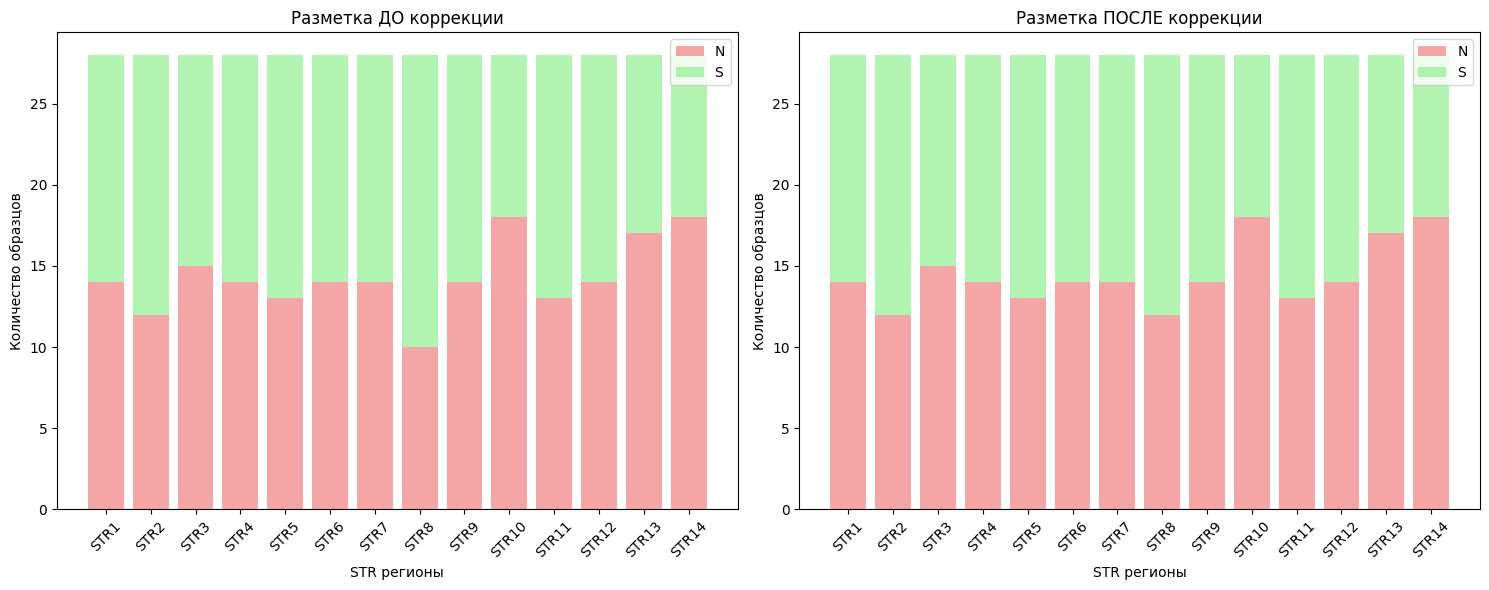

In [23]:
def plot_corrections_comparison(razmetka_original, razmetka_corrected, str_names):
    """
    Визуализирует сравнение разметки до и после коррекции
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # До коррекции
    orig_S_counts = []
    orig_N_counts = []
    for str_name in str_names:
        counts = razmetka_original[str_name].value_counts()
        orig_S_counts.append(counts.get('S', 0))
        orig_N_counts.append(counts.get('N', 0))
    
    # После коррекции
    corr_S_counts = []
    corr_N_counts = []
    for str_name in str_names:
        counts = razmetka_corrected[str_name].value_counts()
        corr_S_counts.append(counts.get('S', 0))
        corr_N_counts.append(counts.get('N', 0))
    
    x = range(len(str_names))
    
    # График до коррекции
    ax1.bar(x, orig_N_counts, label='N', alpha=0.7, color='lightcoral')
    ax1.bar(x, orig_S_counts, bottom=orig_N_counts, label='S', alpha=0.7, color='lightgreen')
    ax1.set_title('Разметка ДО коррекции')
    ax1.set_xlabel('STR регионы')
    ax1.set_ylabel('Количество образцов')
    ax1.legend()
    ax1.set_xticks(x)
    ax1.set_xticklabels(str_names, rotation=45)
    
    # График после коррекции
    ax2.bar(x, corr_N_counts, label='N', alpha=0.7, color='lightcoral')
    ax2.bar(x, corr_S_counts, bottom=corr_N_counts, label='S', alpha=0.7, color='lightgreen')
    ax2.set_title('Разметка ПОСЛЕ коррекции')
    ax2.set_xlabel('STR регионы')
    ax2.set_ylabel('Количество образцов')
    ax2.legend()
    ax2.set_xticks(x)
    ax2.set_xticklabels(str_names, rotation=45)
    
    plt.tight_layout()
    plt.show()

# Визуализируем сравнение
plot_corrections_comparison(razmetka_all_str, razmetka_corrected_advanced, str_names)

In [24]:
# Сохраняем исправленную разметку
razmetka_corrected_advanced.T.to_csv('razmetka_corrected.csv', encoding='utf-8')
print("Исправленная разметка сохранена в razmetka_corrected.csv")

# Сохраняем детальную статистику коррекций
import json
with open('correction_stats.json', 'w', encoding='utf-8') as f:
    # Конвертируем numpy types to Python types для JSON
    stats_serializable = {}
    for str_name, stats in detailed_stats.items():
        stats_serializable[str_name] = {
            'total_samples': stats['total_samples'],
            'S_to_N_corrections': stats['S_to_N_corrections'],
            'avg_entropy': float(stats['avg_entropy']),
            'corrected_samples': stats['corrected_samples']
        }
    json.dump(stats_serializable, f, indent=2, ensure_ascii=False)

print("Статистика коррекций сохранена в correction_stats.json")

Исправленная разметка сохранена в razmetka_corrected.csv
Статистика коррекций сохранена в correction_stats.json


In [25]:
def calculate_correction_percentage(razmetka_original, razmetka_corrected, str_list=None):
    """
    Вычисляет процент изменений между оригинальной и исправленной разметкой
    
    Parameters:
    - razmetka_original: оригинальная разметка DataFrame
    - razmetka_corrected: исправленная разметка DataFrame  
    - str_list: список STR для анализа (если None, все доступные)
    """
    
    if str_list is None:
        str_list = [f'STR{i}' for i in range(1, 15)]  # STR1-STR14
    
    total_corrections = 0
    total_comparisons = 0
    str_corrections = {}
    
    print("=== АНАЛИЗ КОРРЕКЦИЙ РАЗМЕТКИ ===")
    
    for str_name in str_list:
        if str_name not in razmetka_original.columns or str_name not in razmetka_corrected.columns:
            print(f"⚠️  {str_name} отсутствует в данных")
            continue
            
        str_corrections_count = 0
        str_total_samples = 0
        
        # Сравниваем каждую ячейку (только первые 12 строк - образцы 1-12)
        for sample_idx in range(12):  # только первые 12 образцов
            sample_name = f"Sample_{sample_idx + 1}"
            
            if sample_name in razmetka_original.index and sample_name in razmetka_corrected.index:
                original_value = razmetka_original.loc[sample_name, str_name]
                corrected_value = razmetka_corrected.loc[sample_name, str_name]
                
                # Считаем только если оба значения не NaN
                if pd.notna(original_value) and pd.notna(corrected_value):
                    str_total_samples += 1
                    total_comparisons += 1
                    
                    if original_value != corrected_value:
                        str_corrections_count += 1
                        total_corrections += 1
        
        str_corrections[str_name] = {
            'corrections': str_corrections_count,
            'total_samples': str_total_samples,
            'correction_percentage': (str_corrections_count / str_total_samples * 100) if str_total_samples > 0 else 0
        }
        
        print(f"{str_name}: {str_corrections_count}/{str_total_samples} коррекций ({str_corrections[str_name]['correction_percentage']:.1f}%)")
    
    # Общая статистика
    overall_percentage = (total_corrections / total_comparisons * 100) if total_comparisons > 0 else 0
    
    print(f"\n=== ОБЩАЯ СТАТИСТИКА ===")
    print(f"Всего сравнений: {total_comparisons}")
    print(f"Всего коррекций: {total_corrections}")
    print(f"Общий процент коррекций: {overall_percentage:.2f}%")
    
    return {
        'overall_percentage': overall_percentage,
        'total_corrections': total_corrections,
        'total_comparisons': total_comparisons,
        'str_corrections': str_corrections
    }

# Вычисляем процент коррекций
correction_analysis = calculate_correction_percentage(razmetka_all_str, razmetka_corrected_advanced)

=== АНАЛИЗ КОРРЕКЦИЙ РАЗМЕТКИ ===
STR1: 0/12 коррекций (0.0%)
STR2: 0/12 коррекций (0.0%)
STR3: 0/12 коррекций (0.0%)
STR4: 0/12 коррекций (0.0%)
STR5: 0/12 коррекций (0.0%)
STR6: 0/12 коррекций (0.0%)
STR7: 0/12 коррекций (0.0%)
STR8: 2/12 коррекций (16.7%)
STR9: 0/12 коррекций (0.0%)
STR10: 0/12 коррекций (0.0%)
STR11: 0/12 коррекций (0.0%)
STR12: 0/12 коррекций (0.0%)
STR13: 0/12 коррекций (0.0%)
STR14: 0/12 коррекций (0.0%)

=== ОБЩАЯ СТАТИСТИКА ===
Всего сравнений: 168
Всего коррекций: 2
Общий процент коррекций: 1.19%


C:\Users\user\AppData\Local\Temp\ipykernel_15796\3103239598.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(str_names, rotation=45)
C:\Users\user\AppData\Local\Temp\ipykernel_15796\3103239598.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(str_names, rotation=45)


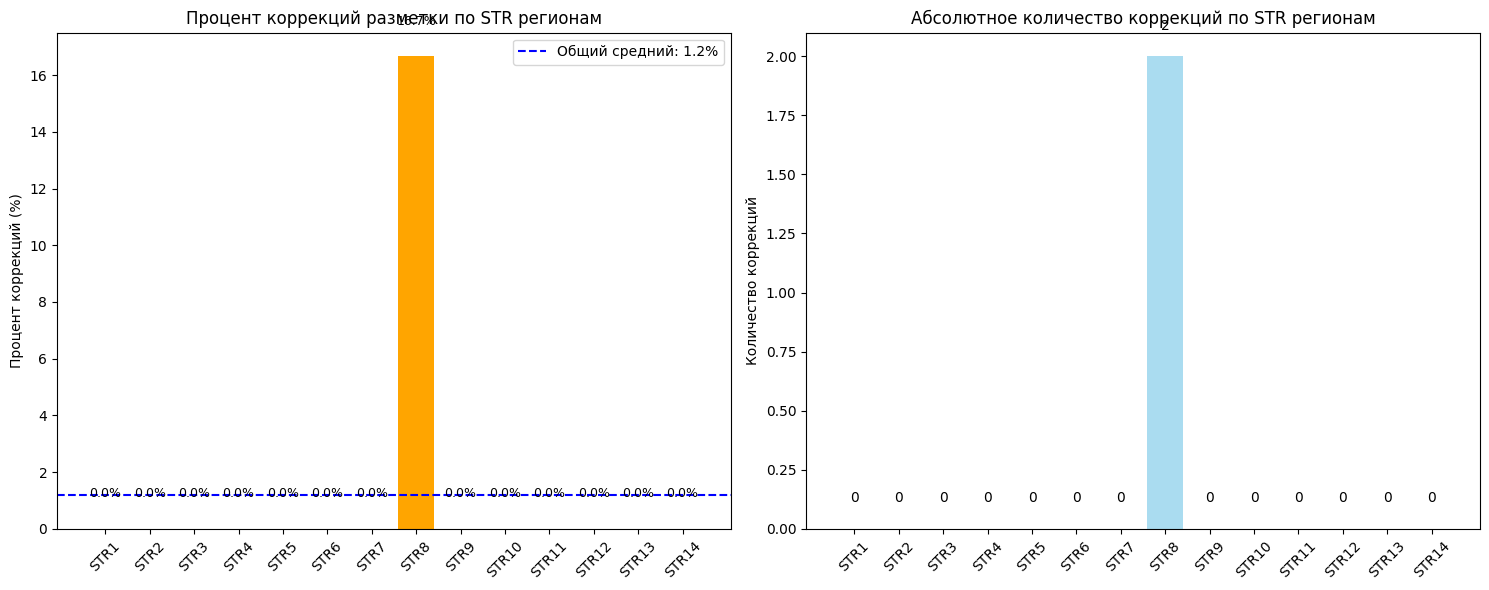

In [26]:
import matplotlib.pyplot as plt

def plot_correction_percentage(correction_analysis):
    """
    Визуализирует процент коррекций по STR
    """
    str_corrections = correction_analysis['str_corrections']
    
    str_names = list(str_corrections.keys())
    percentages = [data['correction_percentage'] for data in str_corrections.values()]
    counts = [data['corrections'] for data in str_corrections.values()]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # График 1: Процент коррекций
    bars = ax1.bar(str_names, percentages, color=['red' if p > 20 else 'orange' if p > 10 else 'green' for p in percentages])
    ax1.axhline(y=correction_analysis['overall_percentage'], color='blue', linestyle='--', 
                label=f'Общий средний: {correction_analysis["overall_percentage"]:.1f}%')
    ax1.set_ylabel('Процент коррекций (%)')
    ax1.set_title('Процент коррекций разметки по STR регионам')
    ax1.set_xticklabels(str_names, rotation=45)
    ax1.legend()
    
    # Добавляем значения на столбцы
    for bar, percentage in zip(bars, percentages):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9)
    
    # График 2: Количество коррекций
    ax2.bar(str_names, counts, color='skyblue', alpha=0.7)
    ax2.set_ylabel('Количество коррекций')
    ax2.set_title('Абсолютное количество коррекций по STR регионам')
    ax2.set_xticklabels(str_names, rotation=45)
    
    # Добавляем значения на столбцы
    for i, count in enumerate(counts):
        ax2.text(i, count + 0.1, str(count), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

# Визуализируем
plot_correction_percentage(correction_analysis)

In [27]:
def interpret_correction_percentage(overall_percentage):
    """
    Интерпретирует общий процент коррекций
    """
    print("=== ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ ===")
    
    if overall_percentage < 5:
        interpretation = "ОТЛИЧНО"
        explanation = "Энтропия Шеннона почти идеально согласуется с экспертной оценкой"
    elif overall_percentage < 15:
        interpretation = "ХОРОШО" 
        explanation = "Энтропия эффективна как инструмент разметки с умеренной коррекцией"
    elif overall_percentage < 25:
        interpretation = "УДОВЛЕТВОРИТЕЛЬНО"
        explanation = "Энтропия полезна как фильтр, но требует значительной экспертной проверки"
    else:
        interpretation = "ТРЕБУЕТ ПЕРЕСМОТРА"
        explanation = "Высокий процент коррекций указывает на слабую корреляцию энтропии с биологической реальностью"
    
    print(f"Общий процент коррекций: {overall_percentage:.2f}%")
    print(f"Оценка: {interpretation}")
    print(f"Объяснение: {explanation}")

# Интерпретируем результаты
interpret_correction_percentage(correction_analysis['overall_percentage'])

=== ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ ===
Общий процент коррекций: 1.19%
Оценка: ОТЛИЧНО
Объяснение: Энтропия Шеннона почти идеально согласуется с экспертной оценкой


In [28]:
# Предполагается, что переменная razmetka_all_str уже создана
# вашим кодом extract_razmetka_all_str_excel_numbering(...)

def convert_razmetka_df_to_dict(razmetka_df):
    """
    Преобразует DataFrame с разметкой в словарь списков.
    
    Parameters:
    - razmetka_df: DataFrame, где столбцы - STR, строки - образцы, значения - метки.
    
    Returns:
    - labels_dict: Словарь, где ключ - STR, значение - список меток.
    """
    labels_dict = {}
    
    # Проходим по каждому столбцу (STR) в DataFrame
    for str_name in razmetka_df.columns:
        # Преобразуем столбец (Series) в список и добавляем в словарь
        labels_dict[str_name] = razmetka_df[str_name].tolist()
        
    return labels_dict

# --- Пример использования ---

# Выполняем преобразование
labels_dict = convert_razmetka_df_to_dict(razmetka_all_str)

# Проверяем результат
print("=== ПРЕОБРАЗОВАННЫЙ СЛОВАРЬ МЕТОК ===")
# Для наглядности выведем метки для первых двух STR
print("Метки для STR1:", labels_dict.get('STR1'))
print("Метки для STR2:", labels_dict.get('STR2'))
print("\nТип данных:", type(labels_dict))
print("Количество ключей в словаре:", len(labels_dict))

=== ПРЕОБРАЗОВАННЫЙ СЛОВАРЬ МЕТОК ===
Метки для STR1: ['N', 'N', 'N', 'N', 'S', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S']
Метки для STR2: ['N', 'N', 'S', 'N', 'N', 'S', 'N', 'N', 'S', 'N', 'N', 'N', 'N', 'N', 'N', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S', 'S']

Тип данных: <class 'dict'>
Количество ключей в словаре: 14


In [29]:
import pandas as pd
import numpy as np

# Предполагается, что all_str_data и labels_data уже определены

def phase1_consolidate_from_dict(str_data_dict, labels_dict):
    """
    Фаза 1: Консолидация данных из словаря DataFrame в один DataFrame для обучения.
    
    Parameters:
    - str_data_dict: Словарь с данными STR (all_str_data)
    - labels_dict: Словарь с метками (labels_data)
    
    Returns:
    - master_df: объединенный DataFrame с признаками и метками
    """
    
    # Шаг 1: Создание контейнера для результата
    # Мы будем собирать обработанные таблицы для каждого STR в этот список
    processed_dfs = []

    # Шаг 2: Итерация и обработка каждого STR
    # Мы проходим по каждому ключу ('STR1', 'STR2', ...) в нашем словаре
    for str_name, str_df in str_data_dict.items():
        
        print(f"--- Обработка {str_name} ---")
        
        # 2a. Транспонирование
        # Сейчас строки = длины, столбцы = образцы. Нам нужно наоборот.
        # .T меняет строки и столбцы местами.
        transposed_df = str_df.T
        # print("Транспонированный DataFrame (первые 5 строк):")
        # print(transposed_df.head())
        
        # 2b. Очистка и переименование
        # Устанавливаем новые, понятные названия для столбцов с долями
        transposed_df.columns = [f"prop_len_{i+1}" for i in range(len(transposed_df.columns))]
        # Сбрасываем индекс, чтобы старые названия длин (Length_1, Length_2...) не стали столбцом
        transposed_df = transposed_df.reset_index(drop=True)
        # print("\nDataFrame после переименования (первые 5 строк):")
        # print(transposed_df.head())
        
        # 2c. Добавление контекстной информации
        # Добавляем столбец с идентификатором образца
        transposed_df['Sample_ID'] = [f"Sample_{i+1}" for i in range(len(transposed_df))]
        
        # Добавляем столбец с названием STR
        transposed_df['STR_ID'] = str_name
        
        # Добавляем столбец с метками из нашего словаря labels_data
        # Мы берем список меток для текущего STR
        current_labels = labels_dict.get(str_name, None)
        if current_labels is None:
            raise ValueError(f"Метки для {str_name} не найдены в словаре labels_data!")
        transposed_df['Label'] = current_labels
        
        # print("\nИтоговый DataFrame для текущего STR (первые 5 строк):")
        # print(transposed_df.head())
        
        # 2d. Сохранение результата
        # Добавляем готовый DataFrame для текущего STR в наш общий список
        processed_dfs.append(transposed_df)
        print(f"{str_name} успешно обработан и добавлен в список.\n")

    # Шаг 3: Объединение всех частей
    # pd.concat "склеивает" все DataFrame из списка в один большой
    master_df = pd.concat(processed_dfs, ignore_index=True)
    
    print("Консолидация всех STR завершена.")
    
    return master_df

# --- Пример использования ---

# Выполняем Фазу 1, используя наши словари
try:
    master_dataframe = phase1_consolidate_from_dict(all_str_data, labels_dict)

    # Шаг 4: Проверка результата
    print("\n" + "="*50)
    print("ИТОГОВЫЙ РЕЗУЛЬТАТ ФАЗЫ 1")
    print("="*50)
    print(f"Размер итогового DataFrame: {master_dataframe.shape}")
    print("\nПервые 5 строк итогового DataFrame:")
    print(master_dataframe.head())
    
    print("\nПоследние 5 строк итогового DataFrame:")
    print(master_dataframe.tail())
    
    print("\nПроверка уникальных значений в столбцах 'STR_ID' и 'Label':")
    print("Уникальные STR_ID:", master_dataframe['STR_ID'].unique())
    print("Количество уникальных меток:", master_dataframe['Label'].value_counts())

except KeyError as e:
    print(f"Ошибка: {e}. Убедитесь, что ключи в словаре all_str_data и labels_data совпадают.")
except Exception as e:
    print(f"Произошла непредвиденная ошибка: {e}")


--- Обработка STR1 ---
STR1 успешно обработан и добавлен в список.

--- Обработка STR2 ---
STR2 успешно обработан и добавлен в список.

--- Обработка STR3 ---
STR3 успешно обработан и добавлен в список.

--- Обработка STR4 ---
STR4 успешно обработан и добавлен в список.

--- Обработка STR5 ---
STR5 успешно обработан и добавлен в список.

--- Обработка STR6 ---
STR6 успешно обработан и добавлен в список.

--- Обработка STR7 ---
STR7 успешно обработан и добавлен в список.

--- Обработка STR8 ---
STR8 успешно обработан и добавлен в список.

--- Обработка STR9 ---
STR9 успешно обработан и добавлен в список.

--- Обработка STR10 ---
STR10 успешно обработан и добавлен в список.

--- Обработка STR11 ---
STR11 успешно обработан и добавлен в список.

--- Обработка STR12 ---
STR12 успешно обработан и добавлен в список.

--- Обработка STR13 ---
STR13 успешно обработан и добавлен в список.

--- Обработка STR14 ---
STR14 успешно обработан и добавлен в список.

Консолидация всех STR завершена.

ИТОГ

In [30]:
import pandas as pd
import numpy as np

def phase2_feature_engineering(master_df):
    """
    Фаза 2: Инженерия признаков.
    Добавляет признаки, описывающие форму распределения, и обрабатывает категориальные переменные.
    
    Parameters:
    - master_df: DataFrame, полученный из Фазы 1.
    
    Returns:
    - final_df: DataFrame с новыми признаками, готовый для обучения модели.
    """
    
    print("--- Начало Фазы 2: Инженерия признаков ---")
    
    # --- Шаг 1: Определение "сырых" признаков ---
    # Это 20 столбцов с долями прочтений
    raw_features = [f"prop_len_{i+1}" for i in range(20)]
    print(f"Определено {len(raw_features)} сырых признаков.")
    
    # --- Шаг 2: Расчет новых признаков, описывающих "форму" ---
    
    # 2a. Стандартное отклонение
    # axis=1 означает, что вычисление идет по строкам (для каждого образца)
    master_df['standard_deviation'] = master_df[raw_features].std(axis=1)
    
    # 2b. Доля самого высокого пика (peak_proportion)
    master_df['peak_proportion'] = master_df[raw_features].max(axis=1)
    
    # 2c. Доля второго по высоте пика (second_peak_proportion)
    # Используем nlargest для надежности
    master_df['second_peak_proportion'] = master_df[raw_features].apply(
        lambda row: row.nlargest(2).iloc[-1] if len(row.nlargest(2)) > 1 else 0, axis=1
    )
    
    # 2d. Количество локальных максимумов (num_peaks)
    # Это самый сложный признак. Мы ищем значения, которые больше своих соседей.
    # Используем векторизованный подход с NumPy для скорости.
    data_array = master_df[raw_features].values
    # Сравниваем каждый элемент (кроме крайних) с соседями
    peaks = (data_array[:, 1:-1] > data_array[:, :-2]) & (data_array[:, 1:-1] > data_array[:, 2:])
    master_df['num_peaks'] = np.sum(peaks, axis=1)
    
    print("Созданы новые признаки: standard_deviation, peak_proportion, second_peak_proportion, num_peaks.")
    
    # --- Шаг 3: Обработка категориального признака STR_ID (One-Hot Encoding) ---
    # Модели не могут работать с текстом 'STR1', 'STR2'. Мы преобразуем их в числовые столбцы.
    # 'is_STR1', 'is_STR2', ..., 'is_STR14', где 1 означает "да, это этот STR", 0 - "нет".
    str_id_dummies = pd.get_dummies(master_df['STR_ID'], prefix='is')
    
    # Объединяем новые one-hot столбцы с основным DataFrame
    master_df = pd.concat([master_df, str_id_dummies], axis=1)
    
    # Удаляем исходный текстовый столбец 'STR_ID', так как он больше не нужен
    master_df.drop('STR_ID', axis=1, inplace=True)
    
    print(f"Выполнено One-Hot Encoding для STR_ID. Добавлено {len(str_id_dummies.columns)} новых столбцов.")
    
    # --- Шаг 4: Финальная подготовка DataFrame ---
    
    # Переставим столбцы для удобства: сначала метка, потом сырые, потом engineered, потом one-hot
    # Это не обязательно для модели, но делает таблицу более читаемой для человека
    
    # Список всех столбцов
    all_cols = list(master_df.columns)
    
    # Определяем группы столбцов
    label_col = ['Label']
    sample_id_col = ['Sample_ID']
    raw_cols = [col for col in all_cols if col.startswith('prop_len_')]
    engineered_cols = ['standard_deviation', 'peak_proportion', 'second_peak_proportion', 'num_peaks']
    one_hot_cols = [col for col in all_cols if col.startswith('is_')]
    
    # Создаем новый порядок
    final_column_order = label_col + sample_id_col + raw_cols + engineered_cols + one_hot_cols
    
    final_df = master_df[final_column_order]
    
    print("\n--- Фаза 2 завершена ---")
    print(f"Итоговый размер DataFrame после инженерии признаков: {final_df.shape}")
    print("\nНовые добавленные столбцы (первые 5 строк):")
    print(final_df[['Sample_ID', 'standard_deviation', 'peak_proportion', 'num_peaks', 'is_STR1', 'is_STR2']].head())
    
    return final_df

# --- Пример использования ---

# Убедитесь, что master_dataframe из Фазы 1 доступен
try:
    final_dataframe = phase2_feature_engineering(master_dataframe)

    # Показываем результат
    print("\n" + "="*50)
    print("ИТОГОВЫЙ РЕЗУЛЬТАТ ФАЗЫ 2")
    print("="*50)
    print(f"Финальный размер DataFrame: {final_dataframe.shape}")
    print("\nСписок всех столбцов в финальном DataFrame:")
    print(final_dataframe.columns.tolist())
    print("\nПервые 3 строки финального DataFrame:")
    print(final_dataframe.head(3))

except NameError:
    print("Ошибка: Переменная 'master_dataframe' не найдена. Пожалуйста, выполните код Фазы 1 сначала.")
except Exception as e:
    print(f"Произошла ошибка: {e}")


--- Начало Фазы 2: Инженерия признаков ---
Определено 20 сырых признаков.
Созданы новые признаки: standard_deviation, peak_proportion, second_peak_proportion, num_peaks.
Выполнено One-Hot Encoding для STR_ID. Добавлено 14 новых столбцов.

--- Фаза 2 завершена ---
Итоговый размер DataFrame после инженерии признаков: (392, 40)

Новые добавленные столбцы (первые 5 строк):
  Sample_ID  standard_deviation  peak_proportion  num_peaks  is_STR1  is_STR2
0  Sample_1            0.057748         0.171404          3     True    False
1  Sample_2            0.077882         0.287670          1     True    False
2  Sample_3            0.075913         0.230144          2     True    False
3  Sample_4            0.106017         0.436811          1     True    False
4  Sample_5            0.090551         0.288022          1     True    False

ИТОГОВЫЙ РЕЗУЛЬТАТ ФАЗЫ 2
Финальный размер DataFrame: (392, 40)

Список всех столбцов в финальном DataFrame:
['Label', 'Sample_ID', 'prop_len_1', 'prop_len_2',

--- Начало Фазы 3: Обучение и оценка модели ---
Первые 10 значений целевой переменной (y) до обработки:
0    N
1    N
2    N
3    N
4    S
5    N
6    N
7    N
8    N
9    N
Name: Label, dtype: object
Размерность признаков (X): (392, 38)
Размерность целевой переменной (y): (392,)
✅ Пропущенных значений в 'Label' (до преобразования) не найдено.

Преобразование меток по словарю: {'S': 0, 'N': 1}
Текстовые метки преобразованы в числовые (0 и 1).
✅ Преобразование прошло успешно, NaN не обнаружено.

Размер обучающей выборки: 313 образцов
Размер тестовой выборки: 79 образцов

Начало обучения модели Random Forest...
Обучение завершено.

--- ОЦЕНКА КАЧЕСТВА МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ ---
Общая точность (Accuracy): 0.7468

Отчет по классификации:
                     precision    recall  f1-score   support

  стабильный (S, 0)       0.73      0.77      0.75        39
нестабильный (N, 1)       0.76      0.72      0.74        40

           accuracy                           0.75        79
      

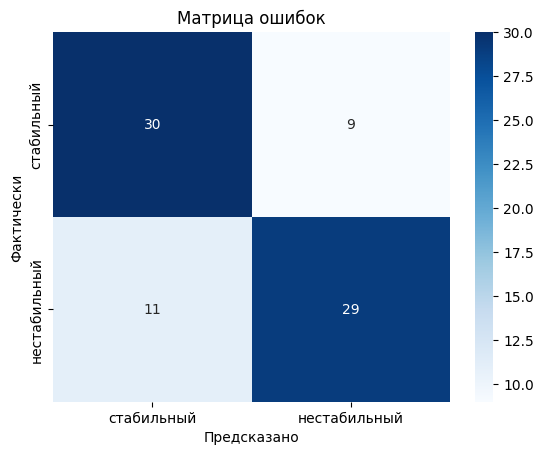


--- 10 САМЫХ ВАЖНЫХ ПРИЗНАКОВ ---
prop_len_7                0.105193
prop_len_8                0.091938
prop_len_6                0.081813
peak_proportion           0.068239
second_peak_proportion    0.061632
prop_len_9                0.060198
prop_len_5                0.054555
prop_len_13               0.054480
prop_len_10               0.052513
standard_deviation        0.050431
dtype: float64


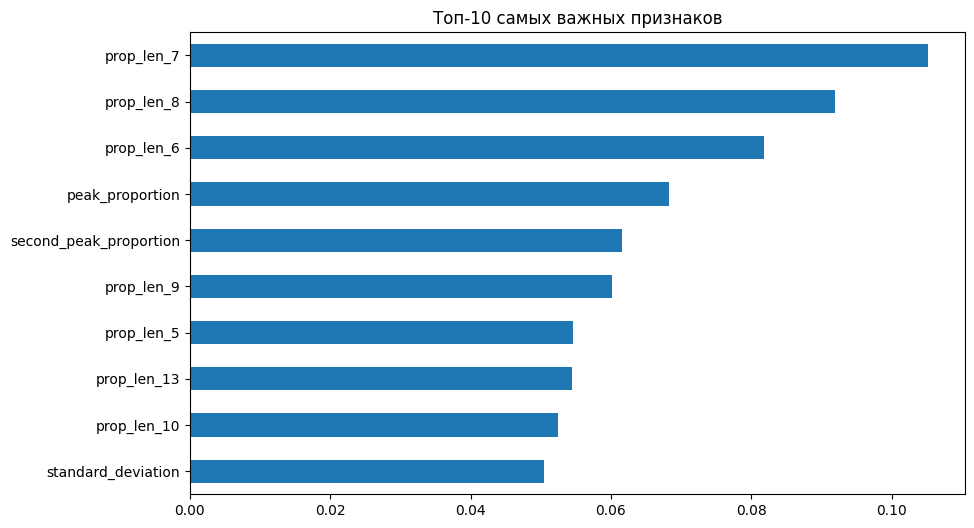


--- Фаза 3 завершена ---


In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def phase3_train_and_evaluate(final_df):
    """
    Фаза 3: Обучение модели Random Forest и ее оценка.
    """
    
    print("--- Начало Фазы 3: Обучение и оценка модели ---")
    
    # --- Шаг 1: Разделение данных на признаки (X) и целевую переменную (y) ---
    X = final_df.drop(['Label', 'Sample_ID'], axis=1)
    y = final_df['Label']
    
    print("Первые 10 значений целевой переменной (y) до обработки:")
    print(y.head(10))
    print(f"Размерность признаков (X): {X.shape}")
    print(f"Размерность целевой переменной (y): {y.shape}")
    
    # --- Шаг 2a: Проверка на наличие NaN в целевой переменной (до преобразования) ---
    if y.isna().any():
        print("❌ ОБНАРУЖЕНЫ NaN В ЦЕЛЕВОЙ ПЕРЕМЕННОЙ!")
        # ... (код для вывода проблемных строк, как и раньше) ...
        raise ValueError("Обучение невозможно, так как в целевой переменной 'Label' есть пропущенные значения (NaN).")
    else:
        print("✅ Пропущенных значений в 'Label' (до преобразования) не найдено.")
    
    # --- Шаг 2: Преобразование текстовых меток в числовые ---
    # ИСПРАВЛЕННЫЙ СЛОВАРЬ: используем 'S' и 'N'
    # Предполагаем: S = Стабильный (0), N = Нестабильный (1)
    label_mapping = {'S': 0, 'N': 1}
    print(f"\nПреобразование меток по словарю: {label_mapping}")
    y = y.map(label_mapping)
    print("Текстовые метки преобразованы в числовые (0 и 1).")
    
    # --- Шаг 2b: Проверка на наличие NaN ПОСЛЕ преобразования ---
    if y.isna().any():
        print("❌ ОБНАРУЖЕНЫ NaN ПОСЛЕ ПРЕОБРАЗОВАНИЯ МЕТОК!")
        print("Это означает, что в столбце 'Label' были значения, отсутствующие в словаре для маппинга.")
        nan_indexes_after_map = y.index[y.isna()].tolist()
        print(f"Найдено {len(nan_indexes_after_map)} таких строк. Их индексы: {nan_indexes_after_map}")
        problem_rows = final_df.loc[nan_indexes_after_map]
        print("\nСтроки с нераспознанными метками:")
        print(problem_rows[['Sample_ID', 'STR_ID', 'Label']])
        raise ValueError("Обучение невозможно. Проверьте словарь для маппинга и уникальные значения в столбце 'Label'.")
    else:
        print("✅ Преобразование прошло успешно, NaN не обнаружено.")
    
    # --- Шаг 3: Разделение на обучающую и тестовую выборки ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\nРазмер обучающей выборки: {X_train.shape[0]} образцов")
    print(f"Размер тестовой выборки: {X_test.shape[0]} образцов")
    
    # --- Шаг 4: Инициализация и обучение модели ---
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    print("\nНачало обучения модели Random Forest...")
    model.fit(X_train, y_train)
    print("Обучение завершено.")
    
    # --- Шаг 5: Оценка качества модели ---
    print("\n--- ОЦЕНКА КАЧЕСТВА МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ ---")
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Общая точность (Accuracy): {accuracy:.4f}")
    
    print("\nОтчет по классификации:")
    print(classification_report(y_test, y_pred, target_names=['стабильный (S, 0)', 'нестабильный (N, 1)']))
    
    print("\nМатрица ошибок:")
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['стабильный', 'нестабильный'], yticklabels=['стабильный', 'нестабильный'])
    plt.xlabel('Предсказано')
    plt.ylabel('Фактически')
    plt.title('Матрица ошибок')
    plt.show()
    
    print("\n--- 10 САМЫХ ВАЖНЫХ ПРИЗНАКОВ ---")
    importances = pd.Series(model.feature_importances_, index=X.columns)
    top_10_importances = importances.sort_values(ascending=False).head(10)
    print(top_10_importances)
    
    plt.figure(figsize=(10, 6))
    top_10_importances.sort_values().plot(kind='barh')
    plt.title('Топ-10 самых важных признаков')
    plt.show()
    
    print("\n--- Фаза 3 завершена ---")
    return model

# --- Пример использования ---
try:
    trained_model = phase3_train_and_evaluate(final_dataframe)
except NameError:
    print("Ошибка: Переменная 'final_dataframe' не найдена. Пожалуйста, выполните код Фазы 1 и Фазы 2 сначала.")
except ValueError as e:
    print(f"\n🔴 КРИТИЧЕСКАЯ ОШИБКА: {e}")
except Exception as e:
    print(f"\nПроизошла непредвиденная ошибка: {e}")



--- Начало Фазы 3: Обучение и оценка модели XGBoost ---
Размер обучающей выборки: 313 образцов
Размер тестовой выборки: 79 образцов

Начало обучения модели XGBoost...
Обучение завершено.

--- ОЦЕНКА КАЧЕСТВА МОДЕЛИ XGBoost НА ТЕСТОВОЙ ВЫБОРКЕ ---
Общая точность (Accuracy): 0.7342

Отчет по классификации:
                     precision    recall  f1-score   support

  стабильный (S, 0)       0.72      0.74      0.73        39
нестабильный (N, 1)       0.74      0.72      0.73        40

           accuracy                           0.73        79
          macro avg       0.73      0.73      0.73        79
       weighted avg       0.73      0.73      0.73        79


Матрица ошибок:


D:\cancer_research_project\cr_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [13:02:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


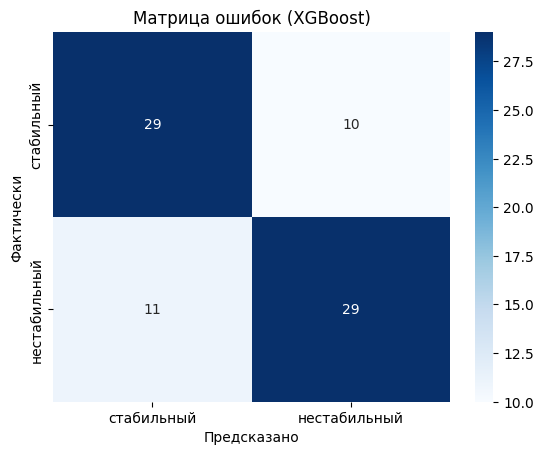


--- 10 САМЫХ ВАЖНЫХ ПРИЗНАКОВ (XGBoost) ---
prop_len_6     0.126477
prop_len_17    0.071158
prop_len_16    0.069325
prop_len_15    0.053879
is_STR1        0.052503
prop_len_8     0.050299
prop_len_14    0.047093
is_STR6        0.046033
prop_len_7     0.044313
prop_len_11    0.039242
dtype: float32


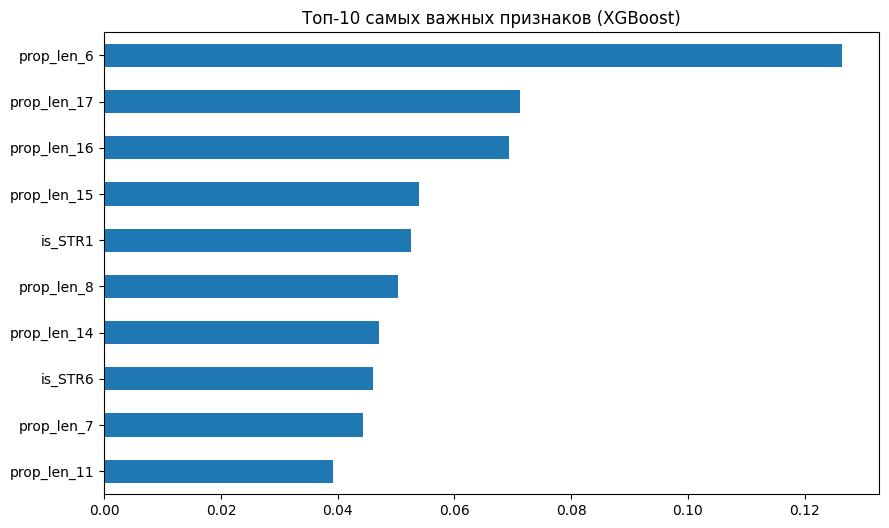


--- Фаза 3 завершена ---


In [32]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Добавляем импорт XGBoost
import xgboost as xgb

def phase3_train_and_evaluate_xgboost(final_df):
    """
    Фаза 3: Обучение модели XGBoost и ее оценка.
    """
    
    print("--- Начало Фазы 3: Обучение и оценка модели XGBoost ---")
    
    # --- Шаг 1: Разделение данных на признаки (X) и целевую переменную (y) ---
    X = final_df.drop(['Label', 'Sample_ID'], axis=1)
    y = final_df['Label']
    
    # --- Шаг 2: Преобразование текстовых меток в числовые ---
    label_mapping = {'S': 0, 'N': 1}
    y = y.map(label_mapping)
    
    # --- Шаг 3: Разделение на обучающую и тестовую выборки ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"Размер обучающей выборки: {X_train.shape[0]} образцов")
    print(f"Размер тестовой выборки: {X_test.shape[0]} образцов")
    
    # --- Шаг 4: Инициализация и обучение модели XGBoost ---
    # use_label_encoder=False и eval_metric='logloss' - чтобы избежать предупреждений
    model = xgb.XGBClassifier(
        objective='binary:logistic', # Задача бинарной классификации
        use_label_encoder=False,
        eval_metric='logloss',
        n_estimators=100,             # Количество деревьев
        learning_rate=0.1,            # Скорость обучения
        random_state=42,
        n_jobs=-1
    )
    
    print("\nНачало обучения модели XGBoost...")
    model.fit(X_train, y_train)
    print("Обучение завершено.")
    
    # --- Шаг 5: Оценка качества модели (остается без изменений) ---
    print("\n--- ОЦЕНКА КАЧЕСТВА МОДЕЛИ XGBoost НА ТЕСТОВОЙ ВЫБОРКЕ ---")
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Общая точность (Accuracy): {accuracy:.4f}")
    
    print("\nОтчет по классификации:")
    print(classification_report(y_test, y_pred, target_names=['стабильный (S, 0)', 'нестабильный (N, 1)']))
    
    print("\nМатрица ошибок:")
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['стабильный', 'нестабильный'], yticklabels=['стабильный', 'нестабильный'])
    plt.xlabel('Предсказано')
    plt.ylabel('Фактически')
    plt.title('Матрица ошибок (XGBoost)')
    plt.show()
    
    print("\n--- 10 САМЫХ ВАЖНЫХ ПРИЗНАКОВ (XGBoost) ---")
    importances = pd.Series(model.feature_importances_, index=X.columns)
    top_10_importances = importances.sort_values(ascending=False).head(10)
    print(top_10_importances)
    
    plt.figure(figsize=(10, 6))
    top_10_importances.sort_values().plot(kind='barh')
    plt.title('Топ-10 самых важных признаков (XGBoost)')
    plt.show()
    
    print("\n--- Фаза 3 завершена ---")
    return model

# --- Пример использования ---
try:
    # Используем ту же переменную final_dataframe, что и раньше
    trained_xgb_model = phase3_train_and_evaluate_xgboost(final_dataframe)

except NameError:
    print("Ошибка: Переменная 'final_dataframe' не найдена.")
except Exception as e:
    print(f"Произошла непредвиденная ошибка: {e}")